## 0. Setup & Installs

In [1]:
# Run once. Restart the kernel afterwards if tensorflow was just installed.
import sys, subprocess

def pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["kagglehub", "opencv-python-headless", "scikit-image", "scikit-learn",
            "pandas", "matplotlib", "seaborn", "tensorflow"]:
    pip_install(pkg)

print("Setup complete.")


Setup complete.


In [2]:
import os, glob, time, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import structural_similarity as ssim
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 96          # resize target for classical + CNN pipelines
N_PER_CLASS = 120       # images sampled per class (raise/lower to taste)
CLASSES_TO_USE = None   # None -> auto-pick 3 classes with most images; or set e.g. ['nv','mel','bkl']

plt.rcParams["figure.figsize"] = (12, 4)


## 1. Download HAM10000 and build the image index
`kagglehub` downloads the dataset (metadata CSV + two image folders) and returns a local path.
This step requires your Kaggle account to be configured (`~/.kaggle/kaggle.json` or Colab's `kagglehub.login()`).

In [3]:
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Path to dataset files:", path)

# Locate the metadata CSV and the two image folders (HAM10000 ships images split across two dirs)
meta_csv = glob.glob(os.path.join(path, "**", "*metadata*.csv"), recursive=True)[0]
img_dirs = [d for d in glob.glob(os.path.join(path, "**", "*"), recursive=True)
            if os.path.isdir(d) and any(f.lower().endswith(".jpg") for f in os.listdir(d)[:50] if os.path.isfile(os.path.join(d, f)))]
print("Metadata:", meta_csv)
print("Image dirs found:", img_dirs)

df_meta = pd.read_csv(meta_csv)

# Map image_id -> full path across all discovered image dirs
image_path_map = {}
for d in img_dirs:
    for fname in os.listdir(d):
        if fname.lower().endswith(".jpg"):
            image_path_map[os.path.splitext(fname)[0]] = os.path.join(d, fname)

df_meta["path"] = df_meta["image_id"].map(image_path_map)
df_meta = df_meta.dropna(subset=["path"]).reset_index(drop=True)
print(df_meta["dx"].value_counts())
df_meta.head()


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000
Metadata: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Image dirs found: ['/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1', '/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1', '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2', '/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2']
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/ham10...


In [4]:
# Diagnosis (dx) legend for reference:
# akiec = Actinic keratoses      bcc  = Basal cell carcinoma
# bkl   = Benign keratosis       df   = Dermatofibroma
# mel   = Melanoma               nv   = Melanocytic nevi
# vasc  = Vascular lesions

if CLASSES_TO_USE is None:
    CLASSES_TO_USE = df_meta["dx"].value_counts().index[:3].tolist()
print("Classes used for Task 1/2/3 demo and classification:", CLASSES_TO_USE)

def sample_class_df(df, classes, n_per_class, seed=SEED):
    parts = []
    for c in classes:
        sub = df[df["dx"] == c]
        n = min(n_per_class, len(sub))
        parts.append(sub.sample(n=n, random_state=seed))
    return pd.concat(parts).reset_index(drop=True)

df_sample = sample_class_df(df_meta, CLASSES_TO_USE, N_PER_CLASS)
print(df_sample["dx"].value_counts())

def load_gray(path, size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return img, gray


Classes used for Task 1/2/3 demo and classification: ['nv', 'mel', 'bkl']
dx
nv     120
mel    120
bkl    120
Name: count, dtype: int64


## Task 1: Comparative Edge Detection
Implements Sobel (Gx, Gy, magnitude), Prewitt, Laplacian, LoG and Canny, and produces the required
`Original -> Sobel -> Prewitt -> Laplacian -> LoG -> Canny` figure for images from at least three classes.

In [5]:
def to_uint8(img):
    img = np.abs(img)
    if img.max() > 0:
        img = img / img.max() * 255
    return img.astype(np.uint8)

def edge_sobel(gray):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.hypot(gx, gy)
    return to_uint8(gx), to_uint8(gy), to_uint8(mag)

def edge_prewitt(gray):
    kx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)
    ky = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
    gx = cv2.filter2D(gray.astype(np.float64), -1, kx)
    gy = cv2.filter2D(gray.astype(np.float64), -1, ky)
    return to_uint8(np.hypot(gx, gy))

def edge_laplacian(gray):
    lap = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
    return to_uint8(lap)

def edge_log(gray, ksize=9, sigma=1.4):
    blur = cv2.GaussianBlur(gray, (ksize, ksize), sigma)
    lap = cv2.Laplacian(blur, cv2.CV_64F, ksize=3)
    return to_uint8(lap)

def edge_canny(gray, low=50, high=150, ksize=3):
    blur = cv2.GaussianBlur(gray, (ksize, ksize), 0) if ksize > 1 else gray
    return cv2.Canny(blur, low, high)

def all_edges(gray):
    gx, gy, mag = edge_sobel(gray)
    return {
        "Sobel Gx": gx, "Sobel Gy": gy, "Sobel Magnitude": mag,
        "Prewitt": edge_prewitt(gray),
        "Laplacian": edge_laplacian(gray),
        "LoG": edge_log(gray),
        "Canny": edge_canny(gray),
    }


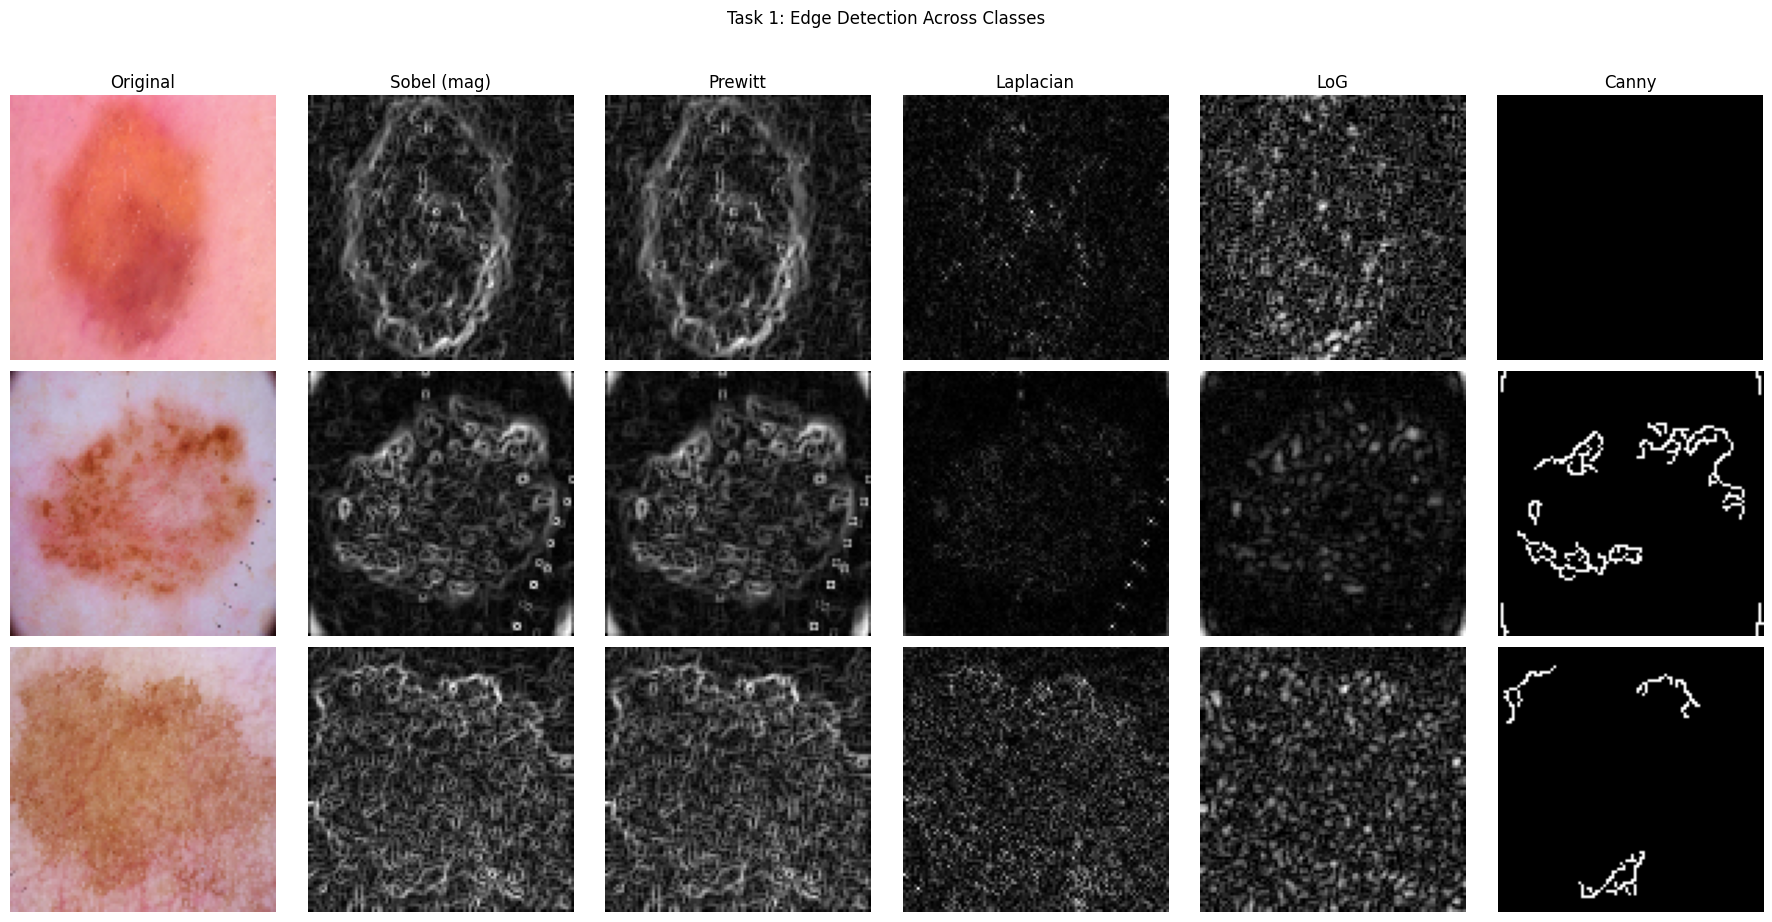

In [6]:
# Required figure: Original -> Sobel -> Prewitt -> Laplacian -> LoG -> Canny, >=3 classes
example_rows = []
for c in CLASSES_TO_USE[:3]:
    row_path = df_sample[df_sample["dx"] == c].iloc[0]["path"]
    example_rows.append((c, row_path))

fig, axes = plt.subplots(len(example_rows), 6, figsize=(18, 3 * len(example_rows)))
col_titles = ["Original", "Sobel (mag)", "Prewitt", "Laplacian", "LoG", "Canny"]

for r, (cls, p) in enumerate(example_rows):
    rgb, gray = load_gray(p)
    edges = all_edges(gray)
    imgs = [rgb, edges["Sobel Magnitude"], edges["Prewitt"], edges["Laplacian"], edges["LoG"], edges["Canny"]]
    for cidx, im in enumerate(imgs):
        ax = axes[r, cidx] if len(example_rows) > 1 else axes[cidx]
        cmap = None if cidx == 0 else "gray"
        ax.imshow(im, cmap=cmap)
        ax.axis("off")
        if r == 0:
            ax.set_title(col_titles[cidx])
    axes[r, 0].set_ylabel(cls, rotation=0, labelpad=40, fontsize=11) if len(example_rows) > 1 else None

plt.suptitle("Task 1: Edge Detection Across Classes", y=1.02)
plt.tight_layout()
plt.savefig("task1_edge_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Task 2: Effect of Noise on Edge Detection
Adds Gaussian and Salt-and-Pepper noise, applies Gaussian/Median filtering, then compares edge maps
quantitatively (edge-pixel density + SSIM against the clean-image edge map) and qualitatively.

In [7]:
def add_gaussian_noise(gray, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, gray.shape)
    noisy = gray.astype(np.float64) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper(gray, amount=0.03, salt_ratio=0.5):
    noisy = gray.copy()
    n_pixels = gray.size
    n_salt = int(amount * n_pixels * salt_ratio)
    n_pepper = int(amount * n_pixels * (1 - salt_ratio))
    coords = [np.random.randint(0, i, n_salt) for i in gray.shape]
    noisy[coords[0], coords[1]] = 255
    coords = [np.random.randint(0, i, n_pepper) for i in gray.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

def gaussian_filter(gray, ksize=5):
    return cv2.GaussianBlur(gray, (ksize, ksize), 0)

def median_filter(gray, ksize=5):
    return cv2.medianBlur(gray, ksize)

def edge_density(edge_img):
    return float(np.count_nonzero(edge_img)) / edge_img.size


In [8]:
DETECTOR_FUNCS = {
    "Sobel": lambda g: edge_sobel(g)[2],
    "Prewitt": edge_prewitt,
    "Laplacian": edge_laplacian,
    "LoG": edge_log,
    "Canny": edge_canny,
}

# Configuration rows mirroring the required Table 1 structure
table1_config = [
    ("Sobel", "Original", "None", "None"),
    ("Sobel", "Noisy", "Gaussian", "None"),
    ("Sobel", "Noisy", "Salt & Pepper", "None"),
    ("Sobel", "Noisy", "Gaussian", "Gaussian Filter"),
    ("Sobel", "Noisy", "Salt & Pepper", "Median Filter"),
    ("Prewitt", "Original", "None", "None"),
    ("Laplacian", "Original", "None", "None"),
    ("LoG", "Noisy", "Gaussian", "Gaussian Filter"),
    ("Canny", "Original", "None", "Built-in smoothing"),
    ("Canny", "Noisy", "Gaussian", "Gaussian Filter"),
    ("Canny", "Noisy", "Salt & Pepper", "Median Filter"),
]

sample_path = example_rows[0][1]
_, base_gray = load_gray(sample_path)
clean_edges_cache = {name: fn(base_gray) for name, fn in DETECTOR_FUNCS.items()}

rows = []
for detector, input_type, noise_type, prep in table1_config:
    fn = DETECTOR_FUNCS[detector]
    gray = base_gray.copy()
    if noise_type == "Gaussian":
        gray = add_gaussian_noise(gray)
    elif noise_type == "Salt & Pepper":
        gray = add_salt_pepper(gray)

    if prep == "Gaussian Filter":
        gray = gaussian_filter(gray)
    elif prep == "Median Filter":
        gray = median_filter(gray)

    edges = fn(gray)
    clean = clean_edges_cache[detector]
    quality_ssim = ssim(clean, edges) if edges.shape == clean.shape else np.nan
    density = edge_density(edges)
    clean_density = edge_density(clean)
    sensitivity = abs(density - clean_density) / (clean_density + 1e-6)

    rows.append({
        "Edge Detector": detector, "Input Image": input_type, "Noise Type": noise_type,
        "Preprocessing": prep, "Edge Quality (SSIM vs clean)": round(quality_ssim, 3),
        "Noise Sensitivity (rel. density change)": round(sensitivity, 3),
        "Observations": ""  # fill in qualitatively after visual inspection
    })

table1_df = pd.DataFrame(rows)
table1_df.to_csv("table1_noise_effect.csv", index=False)
table1_df


,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Quality (SSIM vs clean),Noise Sensitivity (rel. density change),Observations
0,Sobel,Original,None,None,1.000,0.000,
1,Sobel,Noisy,Gaussian,None,0.078,0.004,
2,Sobel,Noisy,Salt & Pepper,None,0.130,0.012,
3,Sobel,Noisy,Gaussian,Gaussian Filter,0.101,0.004,
4,Sobel,Noisy,Salt & Pepper,Median Filter,0.505,0.032,
5,Prewitt,Original,None,None,1.000,0.000,
6,Laplacian,Original,None,None,1.000,0.000,
7,LoG,Noisy,Gaussian,Gaussian Filter,0.076,0.096,
8,Canny,Original,None,Built-in smoothing,1.000,0.000,
9,Canny,Noisy,Gaussian,Gaussian Filter,1.000,0.000,


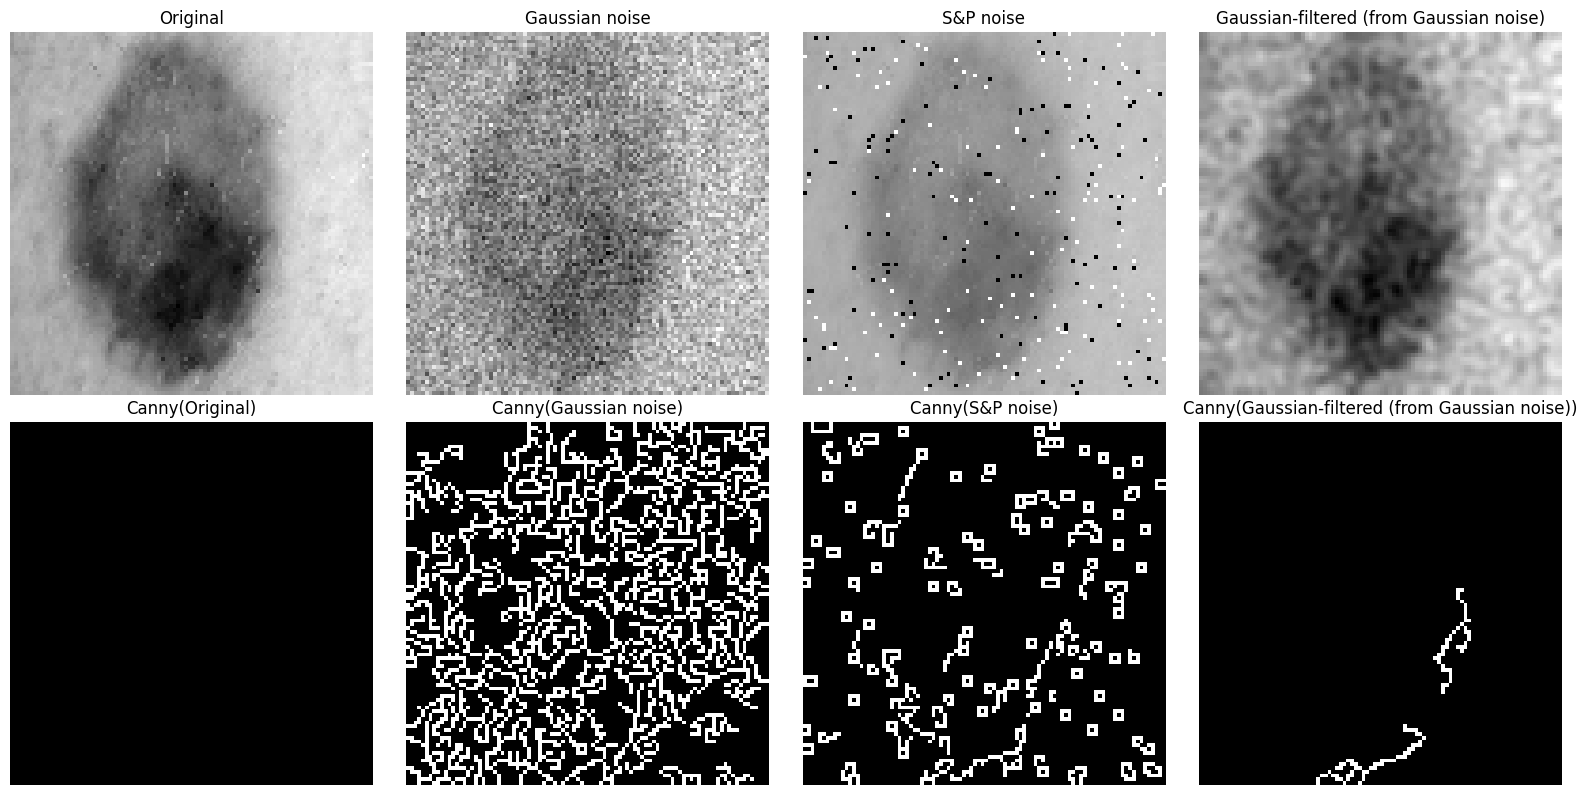

Fill the 'Observations' column of table1_df by inspecting the figure above,
commenting on edge continuity, sharpness, false/broken edges, and noise sensitivity.


In [9]:
# Visual grid to support the written Observations column in Table 1
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
titles = ["Original", "Gaussian noise", "S&P noise", "Gaussian-filtered (from Gaussian noise)"]
gray_variants = [
    base_gray,
    add_gaussian_noise(base_gray),
    add_salt_pepper(base_gray),
    gaussian_filter(add_gaussian_noise(base_gray)),
]
for i, (t, g) in enumerate(zip(titles, gray_variants)):
    axes[0, i].imshow(g, cmap="gray"); axes[0, i].set_title(t); axes[0, i].axis("off")
    axes[1, i].imshow(edge_canny(g), cmap="gray"); axes[1, i].set_title(f"Canny({t})"); axes[1, i].axis("off")
plt.tight_layout()
plt.savefig("task2_noise_edges.png", dpi=150, bbox_inches="tight")
plt.show()

print("Fill the 'Observations' column of table1_df by inspecting the figure above,")
print("commenting on edge continuity, sharpness, false/broken edges, and noise sensitivity.")


## Task 3: Parameter Analysis of Canny Edge Detection

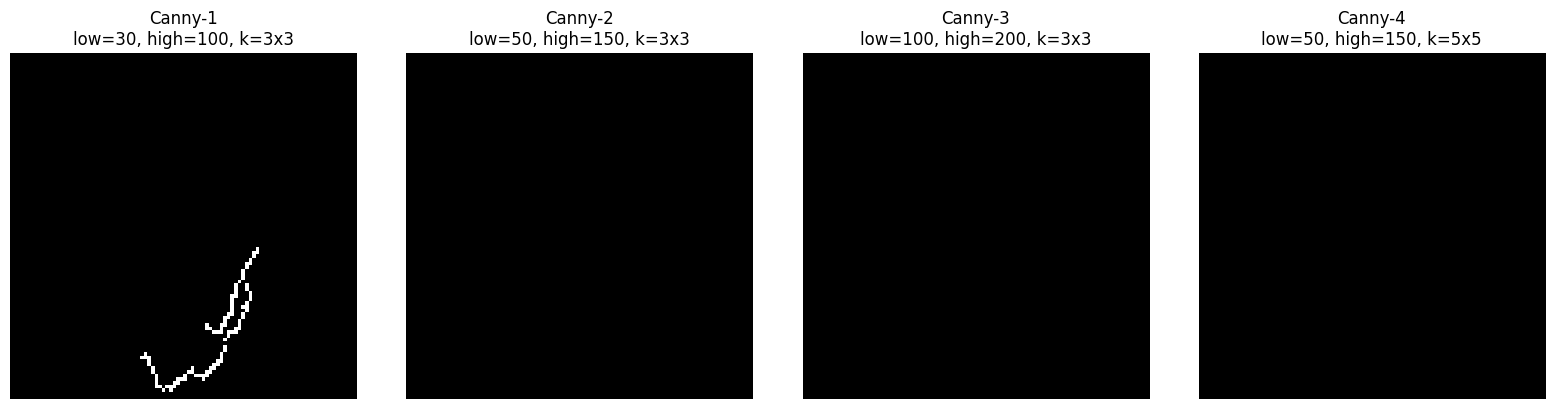

,Configuration,Low Threshold,High Threshold,Kernel Size,Number of Detected Edges,Edge Quality,Observation
0,Canny-1,30,100,3x3,99,,
1,Canny-2,50,150,3x3,0,,
2,Canny-3,100,200,3x3,0,,
3,Canny-4,50,150,5x5,0,,


In [10]:
canny_configs = [
    ("Canny-1", 30, 100, 3),
    ("Canny-2", 50, 150, 3),
    ("Canny-3", 100, 200, 3),
    ("Canny-4", 50, 150, 5),
]

rows = []
fig, axes = plt.subplots(1, len(canny_configs), figsize=(4 * len(canny_configs), 4))
for i, (name, low, high, k) in enumerate(canny_configs):
    edges = edge_canny(base_gray, low=low, high=high, ksize=k)
    n_edges = int(np.count_nonzero(edges))
    axes[i].imshow(edges, cmap="gray")
    axes[i].set_title(f"{name}\nlow={low}, high={high}, k={k}x{k}")
    axes[i].axis("off")
    rows.append({
        "Configuration": name, "Low Threshold": low, "High Threshold": high,
        "Kernel Size": f"{k}x{k}", "Number of Detected Edges": n_edges,
        "Edge Quality": "", "Observation": ""
    })
plt.tight_layout()
plt.savefig("task3_canny_params.png", dpi=150, bbox_inches="tight")
plt.show()

table2_df = pd.DataFrame(rows)
table2_df.to_csv("table2_canny_params.csv", index=False)
table2_df


In [11]:
# Pick the best Canny config to carry into Task 4 (adjust after visual inspection above)
BEST_CANNY = dict(low=50, high=150, ksize=3)
BEST_PREPROCESS = "gaussian"   # or "median" -- set based on Task 2 findings
print("Best Canny config selected:", BEST_CANNY)
print("Best preprocessing/filter selected:", BEST_PREPROCESS)


Best Canny config selected: {'low': 50, 'high': 150, 'ksize': 3}
Best preprocessing/filter selected: gaussian


## Task 4: Classification Using Edge Maps
Builds Set A (raw), Set B (filtered, using the best filter from Task 2), and Set C (edge maps, using
the best Canny configuration from Task 3), all from the same train/val/test split.

In [12]:
def build_dataset(df, size=IMG_SIZE):
    X_raw, X_filt, X_edge, y = [], [], [], []
    for _, row in df.iterrows():
        rgb, gray = load_gray(row["path"], size=size)
        if BEST_PREPROCESS == "gaussian":
            filt = gaussian_filter(gray)
        else:
            filt = median_filter(gray)
        edge = edge_canny(filt, **BEST_CANNY)

        X_raw.append(gray)
        X_filt.append(filt)
        X_edge.append(edge)
        y.append(row["dx"])
    return (np.array(X_raw), np.array(X_filt), np.array(X_edge), np.array(y))

X_raw, X_filt, X_edge, y_labels = build_dataset(df_sample)
le = LabelEncoder()
y = le.fit_transform(y_labels)
print(X_raw.shape, X_filt.shape, X_edge.shape, "classes:", le.classes_)


(360, 96, 96) (360, 96, 96) (360, 96, 96) classes: ['bkl' 'mel' 'nv']


In [13]:
# Same split (indices) reused across all three representations for a fair comparison
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(idx, test_size=0.2, stratify=y, random_state=SEED)
idx_train, idx_val = train_test_split(idx_train, test_size=0.2, stratify=y[idx_train], random_state=SEED)

def split_set(X):
    return X[idx_train], X[idx_val], X[idx_test]

sets = {
    "Raw": split_set(X_raw),
    "Filtered": split_set(X_filt),
    "Edge": split_set(X_edge),
}
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]
print({k: [s.shape for s in v] for k, v in sets.items()})


{'Raw': [(230, 96, 96), (58, 96, 96), (72, 96, 96)], 'Filtered': [(230, 96, 96), (58, 96, 96), (72, 96, 96)], 'Edge': [(230, 96, 96), (58, 96, 96), (72, 96, 96)]}


## Task 5: Classification Performance Comparison
Trains SVM, Random Forest, KNN (on flattened pixel features) and two small CNNs (raw pixel input),
evaluating Accuracy / Precision / Recall / F1 / Training time / Inference time on each of the three
representations (Raw, Filtered, Edge).

In [14]:
def flatten_scale(train, val, test):
    scaler = StandardScaler()
    tr = scaler.fit_transform(train.reshape(len(train), -1))
    va = scaler.transform(val.reshape(len(val), -1))
    te = scaler.transform(test.reshape(len(test), -1))
    return tr, va, te

def eval_classical(model, Xtr, ytr, Xte, yte):
    t0 = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - t0
    t0 = time.time()
    preds = model.predict(Xte)
    infer_time = (time.time() - t0) / len(Xte) * 1000  # ms/sample
    return {
        "Accuracy": accuracy_score(yte, preds),
        "Precision": precision_score(yte, preds, average="macro", zero_division=0),
        "Recall": recall_score(yte, preds, average="macro", zero_division=0),
        "F1-Score": f1_score(yte, preds, average="macro", zero_division=0),
        "Training Time (s)": train_time,
        "Inference Time (ms)": infer_time,
    }, preds


In [15]:
results = {}   # results[(model_name, representation)] = metrics dict
predictions = {}

classical_models = {
    "SVM": lambda: SVC(kernel="rbf", C=10, gamma="scale"),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=200, random_state=SEED),
    "KNN": lambda: KNeighborsClassifier(n_neighbors=5),
}

for rep_name, (train, val, test) in sets.items():
    Xtr, Xva, Xte = flatten_scale(train, val, test)
    for model_name, make_model in classical_models.items():
        metrics, preds = eval_classical(make_model(), Xtr, y_train, Xte, y_test)
        results[(model_name, rep_name)] = metrics
        predictions[(model_name, rep_name)] = preds
        print(rep_name, model_name, metrics)


Raw SVM {'Accuracy': 0.625, 'Precision': 0.6261022927689593, 'Recall': 0.625, 'F1-Score': 0.6239651416122004, 'Training Time (s)': 0.28766345977783203, 'Inference Time (ms)': 1.5884538491566975}
Raw Random Forest {'Accuracy': 0.625, 'Precision': 0.6321428571428571, 'Recall': 0.625, 'F1-Score': 0.6255827505827506, 'Training Time (s)': 2.3824803829193115, 'Inference Time (ms)': 0.21319919162326387}
Raw KNN {'Accuracy': 0.4861111111111111, 'Precision': 0.48484848484848486, 'Recall': 0.48611111111111116, 'F1-Score': 0.48162787293222076, 'Training Time (s)': 0.0025343894958496094, 'Inference Time (ms)': 0.7400910059611002}
Filtered SVM {'Accuracy': 0.6111111111111112, 'Precision': 0.6116938616938618, 'Recall': 0.6111111111111112, 'F1-Score': 0.6106763285024156, 'Training Time (s)': 0.27445387840270996, 'Inference Time (ms)': 1.7813212341732447}
Filtered Random Forest {'Accuracy': 0.5972222222222222, 'Precision': 0.6058115719406042, 'Recall': 0.5972222222222222, 'F1-Score': 0.595622895622895

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

def make_cnn_1(input_shape, n_classes):
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

def make_cnn_2(input_shape, n_classes):
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

CNN_EPOCHS = 15
N_CLASSES = len(le.classes_)

def eval_cnn(make_model_fn, train, val, test, ytr, yva, yte):
    Xtr = train[..., None] / 255.0
    Xva = val[..., None] / 255.0
    Xte = test[..., None] / 255.0
    model = make_model_fn(Xtr.shape[1:], N_CLASSES)
    t0 = time.time()
    model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=CNN_EPOCHS, batch_size=16, verbose=0)
    train_time = time.time() - t0
    t0 = time.time()
    probs = model.predict(Xte, verbose=0)
    infer_time = (time.time() - t0) / len(Xte) * 1000
    preds = probs.argmax(axis=1)
    return {
        "Accuracy": accuracy_score(yte, preds),
        "Precision": precision_score(yte, preds, average="macro", zero_division=0),
        "Recall": recall_score(yte, preds, average="macro", zero_division=0),
        "F1-Score": f1_score(yte, preds, average="macro", zero_division=0),
        "Training Time (s)": train_time,
        "Inference Time (ms)": infer_time,
    }, preds

cnn_models = {"CNN Model 1": make_cnn_1, "CNN Model 2": make_cnn_2}
for rep_name, (train, val, test) in sets.items():
    for model_name, make_fn in cnn_models.items():
        metrics, preds = eval_cnn(make_fn, train, val, test, y_train, y_val, y_test)
        results[(model_name, rep_name)] = metrics
        predictions[(model_name, rep_name)] = preds
        print(rep_name, model_name, metrics)


Raw CNN Model 1 {'Accuracy': 0.625, 'Precision': 0.625555067584053, 'Recall': 0.625, 'F1-Score': 0.6240106896906158, 'Training Time (s)': 24.885812759399414, 'Inference Time (ms)': 14.148251877890694}
Raw CNN Model 2 {'Accuracy': 0.3333333333333333, 'Precision': 0.1111111111111111, 'Recall': 0.3333333333333333, 'F1-Score': 0.16666666666666666, 'Training Time (s)': 15.791603565216064, 'Inference Time (ms)': 20.020633935928345}


Filtered CNN Model 1 {'Accuracy': 0.5694444444444444, 'Precision': 0.5653594771241829, 'Recall': 0.5694444444444445, 'F1-Score': 0.5602996392775719, 'Training Time (s)': 7.869739532470703, 'Inference Time (ms)': 10.917998022503324}
Filtered CNN Model 2 {'Accuracy': 0.3333333333333333, 'Precision': 0.1111111111111111, 'Recall': 0.3333333333333333, 'F1-Score': 0.16666666666666666, 'Training Time (s)': 12.617148160934448, 'Inference Time (ms)': 18.37780409389072}
Edge CNN Model 1 {'Accuracy': 0.4027777777777778, 'Precision': 0.38095238095238093, 'Recall': 0.40277777777777785, 'F1-Score': 0.38717948717948714, 'Training Time (s)': 7.887808322906494, 'Inference Time (ms)': 8.185631699032255}
Edge CNN Model 2 {'Accuracy': 0.3333333333333333, 'Precision': 0.1111111111111111, 'Recall': 0.3333333333333333, 'F1-Score': 0.16666666666666666, 'Training Time (s)': 12.620869874954224, 'Inference Time (ms)': 11.8288430902693}


In [17]:
# Assemble Table 3: Cross-Lab Classification Performance Comparison
model_order = ["SVM", "Random Forest", "KNN", "CNN Model 1", "CNN Model 2"]
rep_order = ["Raw", "Filtered", "Edge"]

table3_rows = []
for model_name in model_order:
    row = {"Model / Classifier": model_name}
    for rep in rep_order:
        row[f"Accuracy {rep}"] = round(results[(model_name, rep)]["Accuracy"], 4)
    # Precision/Recall/F1/time taken from the Edge representation run (or change to preferred rep)
    ref = results[(model_name, "Edge")]
    row["Precision"] = round(ref["Precision"], 4)
    row["Recall"] = round(ref["Recall"], 4)
    row["F1-Score"] = round(ref["F1-Score"], 4)
    row["Training Time (s)"] = round(ref["Training Time (s)"], 3)
    row["Inference Time (ms)"] = round(ref["Inference Time (ms)"], 3)
    table3_rows.append(row)

table3_df = pd.DataFrame(table3_rows)
table3_df.to_csv("table3_classification_comparison.csv", index=False)
table3_df


,Model / Classifier,Accuracy Raw,Accuracy Filtered,Accuracy Edge,Precision,Recall,F1-Score,Training Time (s),Inference Time (ms)
0,SVM,0.6250,0.6111,0.4722,0.5277,0.4722,0.4084,0.287,2.467
1,Random Forest,0.6250,0.5972,0.4444,0.4185,0.4444,0.4131,1.582,0.472
2,KNN,0.4861,0.5000,0.3889,0.3020,0.3889,0.2868,0.003,0.281
3,CNN Model 1,0.6250,0.5694,0.4028,0.3810,0.4028,0.3872,7.888,8.186
4,CNN Model 2,0.3333,0.3333,0.3333,0.1111,0.3333,0.1667,12.621,11.829


## Task 6: Visual Comparison of Classification Results
Confusion matrices for the best-performing model across the three representations, plus a bar chart
comparing Accuracy / Precision / Recall / F1-score.

Best-performing model: SVM {'SVM': np.float64(0.5694444444444445), 'Random Forest': np.float64(0.5555555555555556), 'KNN': np.float64(0.4583333333333333), 'CNN Model 1': np.float64(0.5324074074074074), 'CNN Model 2': np.float64(0.3333333333333333)}


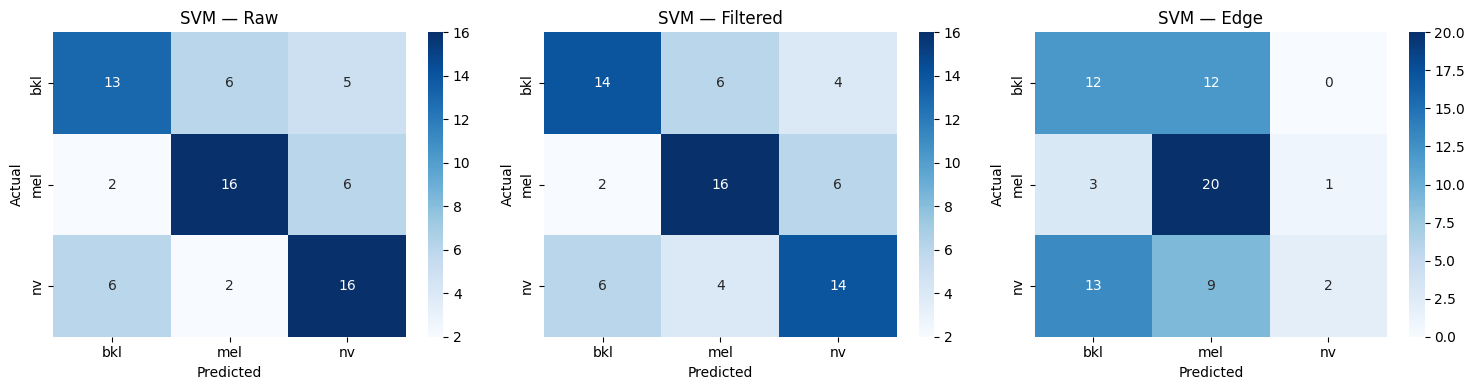

In [18]:
# Identify best-performing model overall (by mean accuracy across representations)
mean_acc = {m: np.mean([results[(m, r)]["Accuracy"] for r in rep_order]) for m in model_order}
best_model = max(mean_acc, key=mean_acc.get)
print("Best-performing model:", best_model, mean_acc)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, rep in enumerate(rep_order):
    cm = confusion_matrix(y_test, predictions[(best_model, rep)])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[i].set_title(f"{best_model} — {rep}")
    axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.savefig("task6_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


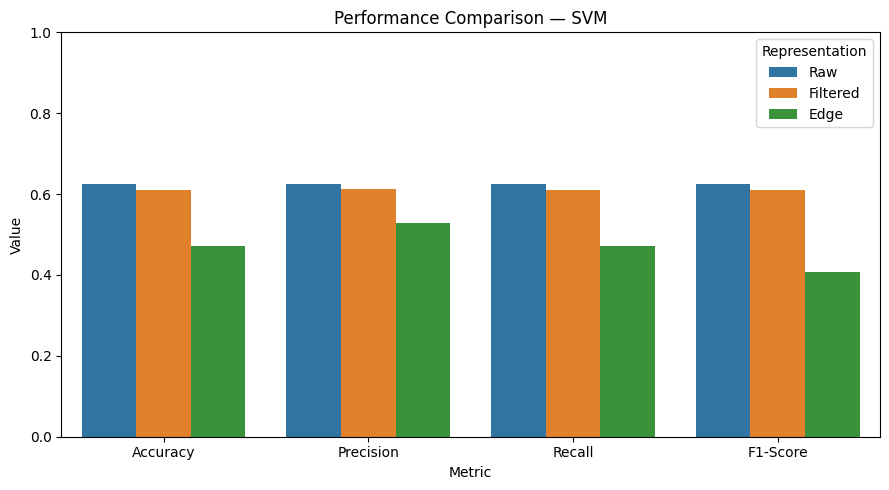

Discuss: did edge detection improve or reduce performance relative to Raw/Filtered for SVM ?


In [19]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
plot_data = []
for rep in rep_order:
    m = results[(best_model, rep)]
    for metric in metrics_to_plot:
        plot_data.append({"Representation": rep, "Metric": metric, "Value": m[metric]})
plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="Metric", y="Value", hue="Representation")
plt.title(f"Performance Comparison — {best_model}")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("task6_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

print("Discuss: did edge detection improve or reduce performance relative to Raw/Filtered for", best_model, "?")


## Discussion Questions (answer in your report after running the cells above)

1. **Edge Detection and Noise** — Compare `Noise Sensitivity` values in `table1_df`; the detector with
   the largest relative density change under noise is the most noise-sensitive (expect Laplacian/LoG,
   since second-derivative operators amplify high-frequency noise).
2. **Effect of Filtering** — Compare SSIM/density for filtered vs. unfiltered noisy rows in `table1_df`;
   Gaussian filtering typically helps Gaussian noise, Median filtering typically helps Salt-and-Pepper noise.
3. **Canny Parameters** — Read `Number of Detected Edges` in `table2_df` across configs: lower thresholds
   → more edges (incl. noise/false edges); higher thresholds → fewer, stronger edges; larger kernel →
   smoother, fewer spurious edges.
4. **Edge Maps and Classification** — Compare the `Accuracy {rep}` columns in `table3_df` for each model.
5. **Information Loss** — Edge maps discard color, texture, and intensity/shading cues, which for skin
   lesion images can include pigmentation patterns and texture irregularities relevant to diagnosis.
6. **Classical vs. Deep Features** — CNNs learn task-optimized, multi-scale edge/texture filters jointly
   with the classifier, rather than a single fixed hand-crafted operator.
7. **Best Representation** — State whichever representation had the highest mean accuracy in `table3_df`,
   and justify using the concrete numbers you obtained.


## Viva Questions — Suggested Answers

1. **What is an edge in an image?** A location where pixel intensity changes sharply, typically marking
   an object boundary or a significant surface/illumination change.
2. **First-order vs. second-order edge detection?** First-order detectors (Sobel, Prewitt) use the first
   derivative (gradient) and find edges as local maxima; second-order detectors (Laplacian, LoG) use the
   second derivative and find edges as zero-crossings.
3. **Sobel Gx vs Gy?** Gx highlights vertical edges (horizontal intensity change); Gy highlights
   horizontal edges (vertical intensity change). The gradient magnitude combines both.
4. **Why is Laplacian more sensitive to noise?** It is a second-derivative operator, which amplifies
   high-frequency content — noise is high-frequency, so it gets amplified along with real edges.
5. **Purpose of Gaussian smoothing before edge detection?** Suppresses high-frequency noise so the
   derivative operators respond mainly to genuine intensity transitions, reducing false edges.
6. **Main advantage of Canny?** It combines noise suppression, non-maximum suppression, and hysteresis
   thresholding, giving thin, well-localized, and more noise-robust edges than simple gradient operators.
7. **Canny's low and high thresholds?** Pixels with gradient magnitude above the high threshold are
   accepted as strong edges; pixels below the low threshold are rejected; pixels in between are kept only
   if connected to a strong edge (hysteresis).
8. **Gaussian vs Salt-and-Pepper noise?** Gaussian noise adds small random variations to every pixel
   following a normal distribution; Salt-and-Pepper noise randomly sets isolated pixels to pure
   black/white (impulse noise).
9. **Why is Median filtering useful for Salt-and-Pepper noise?** It replaces each pixel with the median
   of its neighborhood, which discards extreme outlier values (the salt/pepper pixels) without blurring
   edges as much as a mean/Gaussian filter would.
10. **Why can edge detection reduce classification performance?** It discards color, texture, and
    intensity information that may be discriminative, and can introduce false/broken edges from noise
    or thresholding choices, weakening the features available to the classifier.
11. **Can a CNN learn edge features automatically?** Yes — early convolutional layers commonly learn
    Gabor-like/oriented edge detectors directly from data via gradient-based training.
12. **Why might raw images outperform edge-only images?** Raw images retain color, texture, and shading
    cues (often crucial for tasks like skin lesion classification) that edge maps discard, and avoid
    errors introduced by edge-detection thresholding.


## Learning Outcomes
After completing this lab, you should be able to implement common edge detection techniques; analyze
the effect of noise on edge detection; select suitable preprocessing and edge-detection parameters; use
edge representations for image classification; compare raw, filtered, and edge-based representations;
and relate hand-crafted image features to features learned automatically by a CNN.
